# 3n-DC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/3n-dc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/3n-dc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/3n-dc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/3n-dc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/3n-dc/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [41]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, len(rmsd_cal_center))
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, len(rmsd_cal_center))

In [42]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [43]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

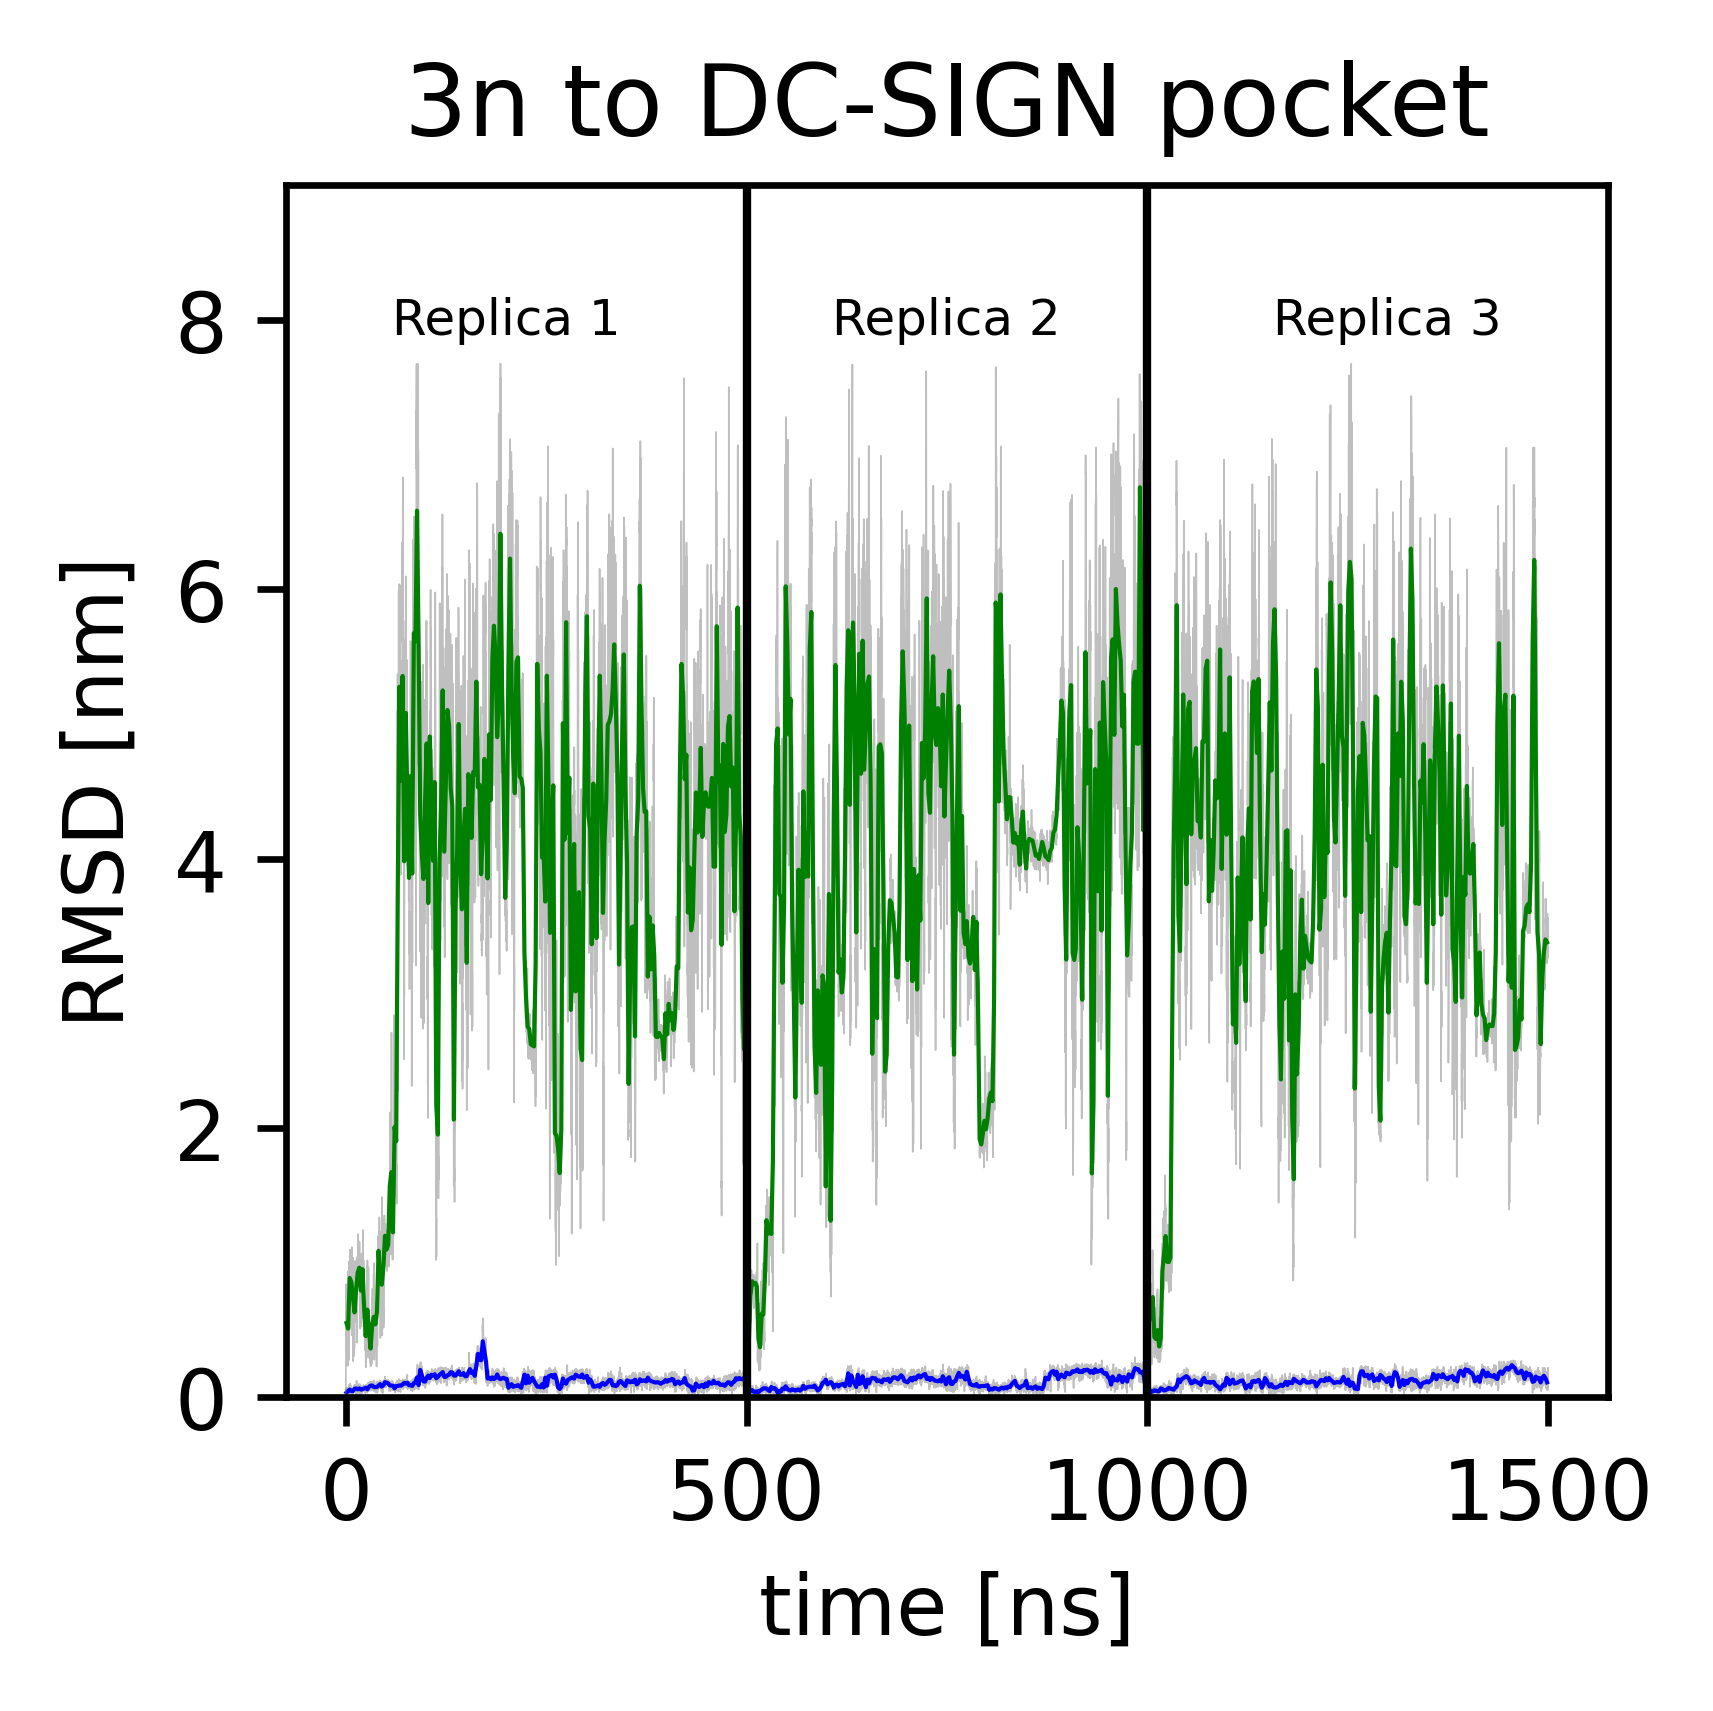

In [47]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('3n to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/3n-dc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu347, HO3 being close to Glu354, HO6 being far away from Glu358 and HO2 being far away from Glu347
- "state A" is defined by HO2 being close to Glu347, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu354
- "state B" is defined by HO2 being close to Glu354, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu347
- "state C" is defined by HO6 being close to Glu358, HO3 being close to Glu354 and HO2 being far from Glu347 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [11]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 358
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 358 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [12]:
# distance 2: HO2 to Glutamic Acid 347
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [13]:
# distance 3: HO3 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 354 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [14]:
# distance 4: HO4 to Glutamic Acid 347 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [15]:
# distance 5: HO2 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 354 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [16]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save(f"{path_stats}distances_flat.npy", distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [17]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

553


In [18]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

90


In [19]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

115


In [20]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [21]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

405

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
However I will only do that if I get more than 100 frames for the state.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 541 frames, 54 ns, 54100 ps
- 2rep bound: 321 frames, 32 ns, 32100 ps
- 3rep bound: 301 frames, 30 ns, 30100 ps

  1163 frames in total -> 116300 ps

### crystal state 

In [23]:
ps = 100 # convert frames into pico seconds 
crystal_ps= [x*ps for x in crystal[:300]] 
print(*crystal_ps)

0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2800 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 5700 6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 7100 7200 7300 7400 7500 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9600 9700 10000 10100 10200 10300 10400 10500 10600 10700 10900 11000 11100 11200 11300 17600 20900 21000 21100 21200 21300 21500 21600 21700 23400 23700 23800 23900 24000 24300 24400 24500 24600 24800 24900 25000 25100 25200 25300 25400 25500 25600 25700 25800 25900 26000 26100 26200 26300 26400 26500 26600 26700 26800 27000 27100 27200 27300 27400 27500 27600 27700 27800 27900 28000 28100 28200 28400 28500 28600 28700 28800 28900 29000 29100 29200 29300 29400 29500 29600 29700 29800 29900 30000 30200 30300 30400 30500 30700 30800 30900 31000 31100 31200 31300 31400 31500 31600 31700 31800 31900 32000 32100 32200 

The first 300 frames are all in replica 1.

### state A has less than 100 frames

### state B

In [24]:
ps = 100 # convert frames into pico seconds 
stateB_ps= [x*ps for x in stateB[:300]] 
print(*stateB_ps)

11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12500 12700 12800 12900 13000 13100 13300 13400 13800 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16300 16400 16500 16600 16700 16800 16900 17000 17100 17200 17300 17400 17700 17800 17900 18000 18100 18200 18300 18400 18500 18600 18700 18800 18900 19000 19100 19200 19300 19400 19500 19600 19700 19800 19900 20000 20100 20200 20300 20400 20500 20600 20700 20800 21800 21900 22000 22100 22200 22300 22400 22500 22600 22700 22800 22900 23000 23100 23200 23300 75600 75700 75900 76000 76100 76200 76300 76400 76500 76600 76700 76800 97200 97300


In [25]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in stateB_ps:
    if i <= 54100:
        print(i)

frames in 1rep:
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12700
12800
12900
13000
13100
13300
13400
13800
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17700
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19300
19400
19500
19600
19700
19800
19900
20000
20100
20200
20300
20400
20500
20600
20700
20800
21800
21900
22000
22100
22200
22300
22400
22500
22600
22700
22800
22900
23000
23100
23200
23300


In [26]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in stateB_ps:
    if i > 54100 and i <= (54100+32100):
        print(i-54100)

frames in 2rep:
21500
21600
21800
21900
22000
22100
22200
22300
22400
22500
22600
22700


In [27]:
# which frames are in replica 3?
print('frames in 3rep:')
for i in stateB_ps:
    if i > (54100+32100):
        print(i-(54100+32100))

frames in 3rep:
11000
11100
